# Direction geometry

Produces Figure 2.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("direction_geometry")
p = results["params"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from src import theory
from src.figstyle import (PALETTE, PT, WIDTH_IN, panel_label,
                          param_colors, save_figure, use_manuscript_style)

use_manuscript_style()
ALPHA_X, ALPHA_Y = p["N"] / p["Dx"], p["N"] / p["Dy"]
RHO_Y = p["rho_y"]
THETA = 2.0                          # signal strength of the reference curve in (a)
THETA_LEVELS = p["theta_levels"]
N_MASKS = p["n_masks"]
RHO_TH = np.linspace(0.05, 1.0, 61)  # retention grid for the predictions
sweep = results["sweep"]


In [3]:
def deg(overlap_sq):
    """Overlap R^2 -> angle in degrees."""
    return np.degrees(np.arccos(np.sqrt(np.clip(overlap_sq, 0.0, 1.0))))

def total_deg(rho_x, theta):
    """Predicted angle of u_hat from u0; 90 degrees below the threshold."""
    return deg(theory.overlaps_at(ALPHA_X, ALPHA_Y, rho_x, RHO_Y, theta)[0])

def floor_deg(rho_x, alpha_x=ALPHA_X):
    """The irreducible angle arccos sqrt(kappa)."""
    return deg(theory.kappa(alpha_x, rho_x))

def retention_at_floor(angle_deg, alpha_x=ALPHA_X):
    """rho_x where the floor equals angle_deg: below this, no theta reaches that angle."""
    k = np.cos(np.radians(angle_deg)) ** 2
    return k / (alpha_x * (1 - k) + k)

# Markers inside the floor, in units of the mask-level standard error
inside = []
for s in sweep:
    ang = deg(s['Rx2']).mean()
    floor = floor_deg(s['rho_x'])
    se_m = float(deg(s['Rx2_by_mask']).std(ddof=1) / np.sqrt(N_MASKS))
    if ang < floor:
        inside.append((floor - ang) / se_m)
print(f'{len(inside)} of {len(sweep)} markers dip below the floor, the deepest by '
      f'{max(inside, default=0.0):.2f} mask-level SE.')

print(f'design rule: 30 deg needs rho_x > {retention_at_floor(30):.2f}, '
      f'15 deg needs rho_x > {retention_at_floor(15):.2f}')


2 of 33 markers dip below the floor, the deepest by 1.53 mask-level SE.
design rule: 30 deg needs rho_x > 0.60, 15 deg needs rho_x > 0.87


Wrote figures/fig2_direction_geometry.pdf


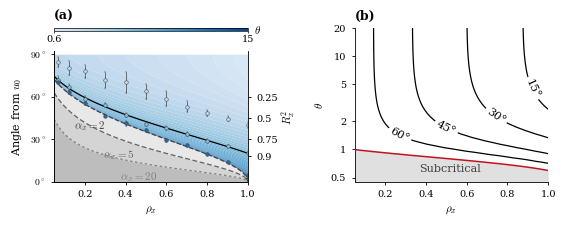

In [4]:
HEIGHT_PT = 150.0
THETA_ALL = np.geomspace(0.59, 15.0, 48)   # signal levels of the color bands
band = np.array([[total_deg(r, th) for r in RHO_TH] for th in THETA_ALL])
ref = np.array([total_deg(r, THETA) for r in RHO_TH])

NORM = LogNorm(vmin=THETA_ALL[0], vmax=THETA_ALL[-1])
cols_all, sm = param_colors('theta', THETA_ALL, norm=NORM, lo=0.16, hi=0.92)
cols_meas, _ = param_colors('theta', np.array(THETA_LEVELS), norm=NORM,
                            lo=0.16, hi=0.92)

FLOOR_ALPHAS = (2.0, 5.0, 20.0)
floors = {a_: np.array([floor_deg(r, a_) for r in RHO_TH]) for a_ in FLOOR_ALPHAS}
theta_c_curve = np.array([theory.theta_c(ALPHA_X, ALPHA_Y, r, RHO_Y) for r in RHO_TH])

fig = plt.figure(figsize=(WIDTH_IN, HEIGHT_PT / 72.0), constrained_layout=True)
fig.get_layout_engine().set(hspace=0.03, wspace=0.06, h_pad=0.01, w_pad=0.02)
gs = fig.add_gridspec(2, 2, height_ratios=[0.075, 3.0])
cax = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[:, 1])

lowest_alpha = min(FLOOR_ALPHAS)
ax.fill_between(RHO_TH, floors[lowest_alpha], band[-1], color=cols_all[-1],
                lw=0, zorder=1)
for i in range(len(THETA_ALL) - 1):
    ax.fill_between(RHO_TH, band[i + 1], band[i], color=cols_all[i], lw=0,
                    zorder=1)

ordered_floors = sorted(FLOOR_ALPHAS, reverse=True)
shade_colors = ['0.74', '0.83', '0.91']
lower = np.zeros_like(RHO_TH)
for alpha, shade in zip(ordered_floors, shade_colors):
    ax.fill_between(RHO_TH, lower, floors[alpha], color=shade, lw=0, zorder=2)
    lower = floors[alpha]

line_styles = ('--', (0, (4, 2)), (0, (2, 2)))
line_colors = ('0.25', '0.38', '0.50')
label_rho = [0.30, 0.45, 0.56]
for alpha, rho_label, style, color in zip(FLOOR_ALPHAS, label_rho, line_styles, line_colors):
    ax.plot(RHO_TH, floors[alpha], ls=style, color=color, lw=0.9, zorder=5)
    i_lab = int(np.argmin(np.abs(RHO_TH - rho_label)))
    ax.annotate(rf'$\alpha_x={alpha:g}$',
                (RHO_TH[i_lab], floors[alpha][i_lab]),
                textcoords='offset points', xytext=(0, -2.5),
                fontsize=PT['annot'], color=color, ha='right', va='top',
                zorder=8)

ax.plot(RHO_TH, ref, '-', color=PALETTE['theory'], lw=0.9, zorder=6)
for c, th in zip(cols_meas, THETA_LEVELS):
    sel = [s for s in sweep if s['theta'] == th]
    x = np.array([s['rho_x'] for s in sel])
    y = np.array([deg(s['Rx2']).mean() for s in sel])
    sd = np.array([deg(s['Rx2']).std(ddof=1) for s in sel])
    ax.errorbar(x, y, yerr=sd, fmt='o', ms=2.6, mec='0.25', mew=0.35, color=c,
                ecolor='0.25', elinewidth=0.5, capsize=1.0, ls='none', zorder=7)

ax.set_xlim(0.05, 1.0)
ax.set_ylim(0, 92)
ax.set_yticks([0, 30, 60, 90])
ax.set_yticklabels([r'$0^\circ$', r'$30^\circ$', r'$60^\circ$', r'$90^\circ$'])
ax.set_ylabel(r'Angle from $u_0$')
ax.set_xlabel(r'$\rho_x$')

axr = ax.twinx()
axr.set_ylim(ax.get_ylim())
R2_TICKS = (0.9, 0.75, 0.5, 0.25)
axr.set_yticks([deg(v) for v in R2_TICKS])
axr.set_yticklabels([f'{v:g}' for v in R2_TICKS])
axr.set_ylabel(r'$R_x^2$', labelpad=1)
axr.tick_params(length=2.5, width=0.6)
axr.spines['right'].set_visible(True)
axr.spines['right'].set_linewidth(0.6)

cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_ticks([THETA_ALL[0], THETA_ALL[-1]])
cb.set_ticklabels(['0.6', '15'])
cb.ax.tick_params(labelsize=PT['tick'], length=1.5, width=0.5, pad=1)
cb.ax.minorticks_off()
cb.outline.set_linewidth(0.5)
cax.text(1.03, 0.5, r'$\theta$', transform=cax.transAxes, ha='left', va='center',
         fontsize=PT['annot'])
panel_label(cax, '(a)')

TH_GRID = np.geomspace(0.45, 20.0, 46)
field = np.array([[total_deg(r, th) for r in RHO_TH] for th in TH_GRID])
LEVELS = [15.0, 30.0, 45.0, 60.0]   # contour angles in degrees

ax2.set_yscale('log')
ax2.fill_between(RHO_TH, TH_GRID[0], theta_c_curve, color='0.88', lw=0, zorder=1)
ax2.plot(RHO_TH, theta_c_curve, '-', color=PALETTE['threshold'], lw=1.1, zorder=3,
         solid_capstyle='round')
cs = ax2.contour(RHO_TH, TH_GRID, field, levels=LEVELS,
                 colors=[PALETTE['theory']], linewidths=0.9, zorder=5)
manual = []
label_rho = (0.92, 0.74, 0.50, 0.27)
for lvl, x_lab in zip(LEVELS, label_rho):
    col_at = field[:, int(np.argmin(np.abs(RHO_TH - x_lab)))]
    manual.append((x_lab, np.interp(-lvl, -col_at, TH_GRID)))
ax2.clabel(cs, fmt=lambda v: f'{v:.0f}\u00b0', fontsize=PT['annot'], inline=True,
           inline_spacing=3, manual=manual, colors=PALETTE['theory'])
ax2.text(0.52, 0.62, 'Subcritical', fontsize=PT['annot'], color='0.25',
         ha='center', va='center', zorder=8)
ax2.set_xlim(0.05, 1.0)
ax2.set_ylim(TH_GRID[0], TH_GRID[-1])
contour_ticks = [0.5, 1, 2, 5, 10, 20]
ax2.set_yticks(contour_ticks)
ax2.set_yticklabels([f'{value:g}' for value in contour_ticks])
ax2.minorticks_off()
ax2.set_xlabel(r'$\rho_x$')
ax2.set_ylabel(r'$\theta$')
panel_label(ax2, '(b)')

save_figure(fig, 'fig2_direction_geometry')
plt.show()
